<a href="https://colab.research.google.com/github/harihara2004/codemax_internship_module1/blob/main/Module5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load all 5 datasets
df_sales = pd.read_csv('ecommerce_sales_customer_analytics_150k.csv')
df_items = pd.read_csv('order_items.csv')
df_customers = pd.read_csv('customer_master.csv')
df_products = pd.read_csv('product_catalog.csv')
df_stats = pd.read_csv('dataset_statistics.csv')

print("Datasets Loaded Successfully!")
print(f"Sales Records: {df_sales.shape}")
print(f"Order Items: {df_items.shape}")
print(f"Customer Master: {df_customers.shape}")
print(f"Product Catalog: {df_products.shape}")

Datasets Loaded Successfully!
Sales Records: (2969, 46)
Order Items: (11106, 12)
Customer Master: (11765, 11)
Product Catalog: (1175, 9)


In [2]:
# Merge primary sales data with customer master information for deep customer analytics
merged_df = df_sales.merge(df_customers[['customer_id', 'customer_acquisition_cost']], on='customer_id', how='left', suffixes=('', '_master'))

print("--- Overall Business Performance Summary ---")
total_revenue = merged_df['net_sales'].sum()
total_profit = merged_df['profit'].sum()
avg_order_value = merged_df['net_sales'].mean()
print(f"Total Net Revenue Computed: ${total_revenue:,.2f}")
print(f"Total Profit Computed: ${total_profit:,.2f}")
print(f"Average Order Value (AOV): ${avg_order_value:.2f}")

# Analyze Sales Channels and Order Statuses
print("\nSales Channel Breakdown:")
print(merged_df['sales_channel'].value_counts(normalize=True) * 100)

print("\nOrder Status Distribution:")
print(merged_df['order_status'].value_counts(normalize=True) * 100)

--- Overall Business Performance Summary ---
Total Net Revenue Computed: $3,885,180.81
Total Profit Computed: $1,669,619.21
Average Order Value (AOV): $1308.58

Sales Channel Breakdown:
sales_channel
Mobile App      40.720781
Website         34.826541
Marketplace     14.853486
Social Media     9.599192
Name: proportion, dtype: float64

Order Status Distribution:
order_status
Completed    82.081509
Cancelled     6.601549
Returned      6.231054
Pending       5.085888
Name: proportion, dtype: float64


/tmp/ipykernel_928/3120217907.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='customer_segment', y='profit', data=merged_df, estimator=sum, ci=None, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_928/3120217907.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_segment', y='profit', data=merged_df, estimator=sum, ci=None, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_928/3120217907.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='shipping_method', y='delivery_days', data=merged_df, ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_928/3120217907.py:11: UserWarning: set_ticklabels() should only be used w

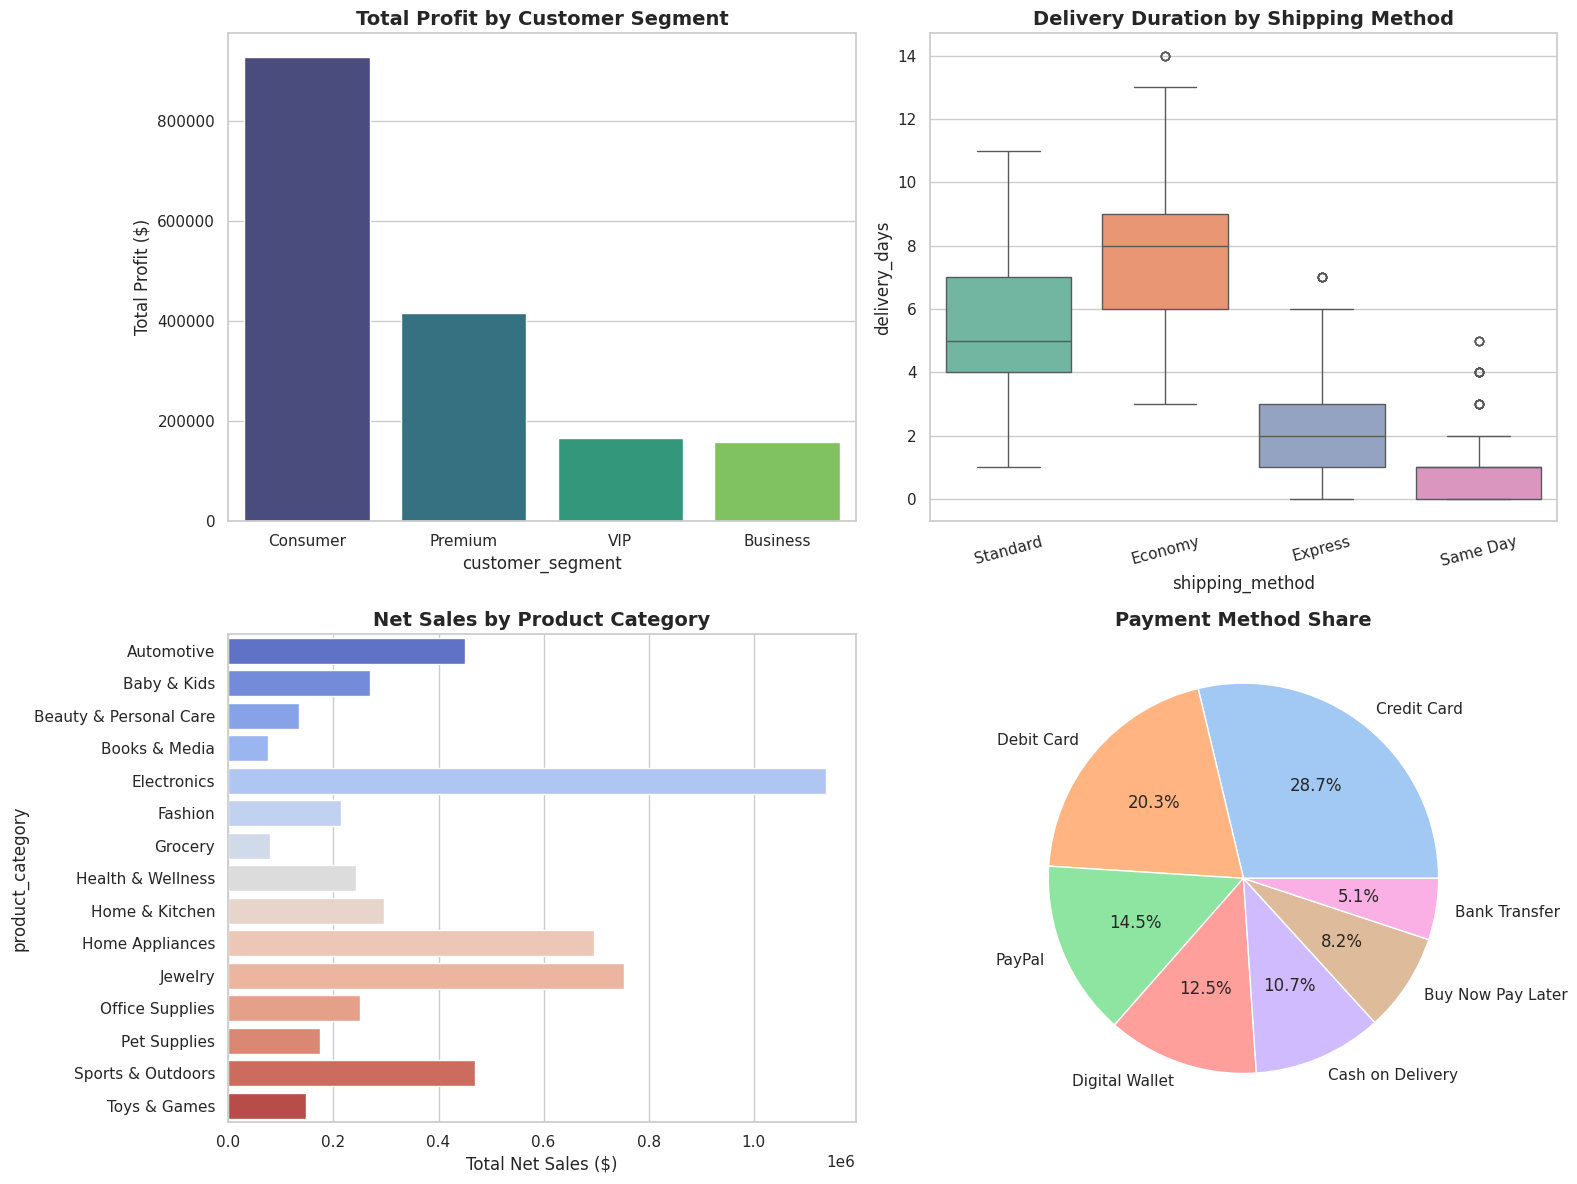

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Profitability by Customer Segment
sns.barplot(x='customer_segment', y='profit', data=merged_df, estimator=sum, ci=None, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Total Profit by Customer Segment', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Total Profit ($)')

# 2. Shipping Method vs Delivery Days
sns.boxplot(x='shipping_method', y='delivery_days', data=merged_df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Delivery Duration by Shipping Method', fontsize=14, fontweight='bold')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=15)

# 3. Top Product Categories by Net Sales (via Product Catalog)
prod_merged = df_items.merge(df_products, on='product_id', how='left')
cat_sales = prod_merged.groupby('product_category')['net_sales'].sum().reset_index()
sns.barplot(x='net_sales', y='product_category', data=cat_sales, ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Net Sales by Product Category', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Total Net Sales ($)')

# 4. Payment Methods Distribution
merged_df['payment_method'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1, 1], colors=sns.color_palette('pastel'))
axes[1, 1].set_title('Payment Method Share', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.savefig('omnichannel_analytics_insights.png', dpi=300)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Prepare customer-level aggregated features for CLV prediction
customer_agg = merged_df.groupby('customer_id').agg({
    'net_sales': ['sum', 'mean', 'count'],
    'profit': 'sum',
    'customer_age': 'first',
    'customer_acquisition_cost': 'first',
    'loyalty_points_earned': 'sum'
}).reset_index()

customer_agg.columns = ['customer_id', 'total_spend', 'avg_order_spend', 'order_count', 'total_profit', 'customer_age', 'cac', 'loyalty_earned']

# Define Target: Customer Lifetime Value (total_spend)
X = customer_agg[['avg_order_spend', 'order_count', 'total_profit', 'customer_age', 'cac', 'loyalty_earned']]
y = customer_agg['total_spend']

X_train, X_test, y_train, y_test = train_test_spin = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("--- Machine Learning Model Results (CLV Prediction) ---")
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Feature Importances
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop Predictive Features for Customer Value:")
print(importances)

--- Machine Learning Model Results (CLV Prediction) ---
R-squared Score: 0.9976
Root Mean Squared Error (RMSE): 60.96

Top Predictive Features for Customer Value:
avg_order_spend    0.818275
loyalty_earned     0.137422
order_count        0.032099
total_profit       0.011634
customer_age       0.000453
cac                0.000117
dtype: float64
